# Library import

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# NLP Libraies

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
import re



# Machine Learning & Metrics

In [37]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import umap
from umap import UMAP

from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans

import hdbscan;
from sklearn.cluster  import DBSCAN 

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import fcluster


import matplotlib.pyplot as plt
import seaborn as sns


# Ensure NLTK resources are downloaded
"""nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')"""

"nltk.download('punkt')\nnltk.download('stopwords')\nnltk.download('wordnet')\nnltk.download('omw-1.4')"

# Environment & Data Loading

In [9]:
print("Loading raw dataset...")
maindataset = pd.read_excel("DATASET15000.xlsx") 
print(maindataset.head())
print("Columns:", maindataset.columns)
print(maindataset.info())

print("Missing values in 'text':", maindataset['Text'].isna().sum())
print("Missing values in 'source':", maindataset['Source'].isna().sum())
print("\nSource distribution:\n", maindataset['Source'].value_counts())
print(maindataset['Document_id'].head(10))


Loading raw dataset...
  Document_id                                               Text  Source
0    POL_0001  > *The following text is extracted and transfo...  policy
1    POL_0002  > *The following text is extracted and transfo...  policy
2    POL_0003  > *The following text is extracted and transfo...  policy
3    POL_0004  > *The following text is extracted and transfo...  policy
4    POL_0005  > *The following text is extracted and transfo...  policy
Columns: Index(['Document_id', 'Text', 'Source'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document_id  15000 non-null  str  
 1   Text         15000 non-null  str  
 2   Source       15000 non-null  str  
dtypes: str(3)
memory usage: 58.1 MB
None
Missing values in 'text': 0
Missing values in 'source': 0

Source distribution:
 Source
policy       5000
judgement    5000
contracts    

# Suffuling Dataset..

In [ ]:
np.random.seed(123)
shuffledataset = maindataset.sample(frac=1, random_state=123).reset_index(drop=True)
#shuffledataset.to_excel("/Users/jannatunnesajerin/DATA SCIENCE PAPER WORK UNSPERVIDED LEARNING/shuffled_dataset.xlsx", index=False)"""

df_model = shuffledataset[["Document_id", "Text"]].copy()
print(df_model.columns)
print(df_model.head())
df_model.to_excel("dataset_without_source.xlsx", index=False)


Index(['Document_id', 'Text'], dtype='str')
  Document_id                                               Text
0   jug_13299  Case Citation #3958 - Judicial Opinion: The fa...
1   jug_13875  Case Citation #4534 - Judicial Opinion: A benc...
2    POL_2976  > *The following text is extracted and transfo...
3    POL_3904  > *The following text is extracted and transfo...
4   jug_14778  Case Citation #5437 - Judicial Opinion: In thi...


# Text Preprocessing

In [21]:
print("Starting text preprocessing...")
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
punctuation_table = str.maketrans('', '', string.punctuation)

def clean_text_optimized(text):
    if not isinstance(text, str):
        return ""
    # Lowercase & remove punctuation/numbers
    text = text.lower()
    text = text.translate(punctuation_table)
    text = ''.join([i for i in text if not i.isdigit()])
    
    # Tokenize, remove stopwords, and Lemmatize
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Re-join into a single string
    return " ".join(cleaned_tokens)

# Map text cleaning function across the 15k rows
df_model['cleaned_text'] = df_model['Text'].apply(clean_text_optimized)

df_clean = df_model[["Document_id", "cleaned_text"]].rename(columns={"cleaned_text": "text"})
print(df_clean.head())
df_clean.to_excel("/Users/jannatunnesajerin/DATA SCIENCE PAPER WORK UNSPERVIDED LEARNING/processed_corpus.xlsx", index=False)



Starting text preprocessing...
  Document_id                                               text
0   jug_13299  case citation judicial opinion family law appe...
1   jug_13875  case citation judicial opinion bench judge pre...
2    POL_2976  following text extracted transformed acponline...
3    POL_3904  following text extracted transformed adswalein...
4   jug_14778  case citation judicial opinion maritime litiga...


# TF_IDF

In [28]:
print("Loading corpus dataset...")
corpus= pd.read_excel("/Users/jannatunnesajerin/DATA SCIENCE PAPER WORK UNSPERVIDED LEARNING/processed_corpus.xlsx") 
print(corpus.head())
print("Columns:", corpus.columns)

corpus['text'] = corpus['text'].fillna("")

# min_df=0.002 retains terms appearing in at least 30 documents out of 15,000
tfidf_vec = TfidfVectorizer(min_df=0.002, max_df=0.99) 
tfidf_matrix = tfidf_vec.fit_transform(corpus['text'])
print(f"TF-IDF Vectorization complete! Matrix shape: {tfidf_matrix.shape}")

 
# Convert the sparse matrix into a readable DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vec.get_feature_names_out()
)
 
# Display the first few rows of the matrix
tfidf_df.head()
 

Loading corpus dataset...
  Document_id                                               text
0   jug_13299  case citation judicial opinion family law appe...
1   jug_13875  case citation judicial opinion bench judge pre...
2    POL_2976  following text extracted transformed acponline...
3    POL_3904  following text extracted transformed adswalein...
4   jug_14778  case citation judicial opinion maritime litiga...
Columns: Index(['Document_id', 'text'], dtype='str')
TF-IDF Vectorization complete! Matrix shape: (15000, 4217)


,ab,abc,abide,abiding,ability,able,abn,abroad,absence,absolute,...,youd,youll,young,younger,youre,youtube,youve,zealand,zip,zone
0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.007792,0.01444,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# umap

In [29]:
print("Running UMAP dimensionality reduction...")
umap_model = umap.UMAP(n_components=2, random_state=42, n_jobs=-1)
umap_coords = umap_model.fit_transform(tfidf_matrix)

umap_df = pd.DataFrame(umap_coords, columns=['UMAP1', 'UMAP2'])
print("UMAP complete! Dimension Head:")
print(umap_df.head())


Running UMAP dimensionality reduction...


/Users/jannatunnesajerin/Desktop/Information /jbooks/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete! Dimension Head:
       UMAP1      UMAP2
0  11.692395 -10.539963
1 -10.822248  -8.181314
2   4.177557  -0.646343
3   6.096614  -0.597851
4  16.832766  12.369740


# k-means

Calculating K-Means Elbow values...


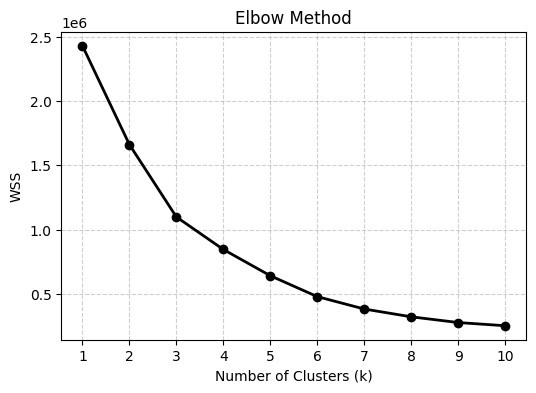


K-Means Cluster Counts:
 kmcluster
0    6956
1    5711
2    2333
Name: count, dtype: int64


In [32]:
# --- A. K-Means Elbow Method ---
print("Calculating K-Means Elbow values...")
wss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(umap_df)
    wss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, wss, marker='o', linewidth=2, color='black')
plt.xticks(K_range)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WSS")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Final K-Means Execution
km_final = KMeans(n_clusters=3, n_init=25, random_state=42)
umap_df['kmcluster'] = km_final.fit_predict(umap_df).astype(str)
print("\nK-Means Cluster Counts:\n", umap_df['kmcluster'].value_counts())


# dbscan

Calculating k-NN Distance Plot for DBSCAN...


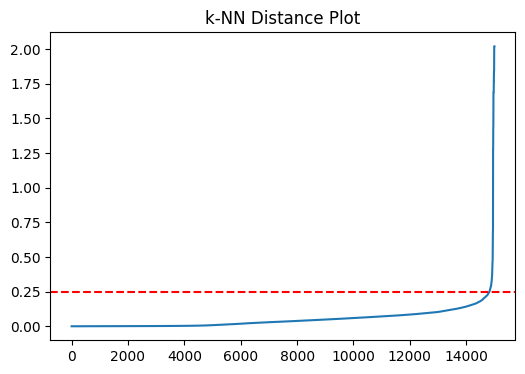


DBSCAN Cluster Counts (-1 is Noise):
 cluster
4      3883
2      3426
38      307
75      210
30      143
       ... 
137      11
142      11
144      11
8        10
139      10
Name: count, Length: 146, dtype: int64


In [54]:
print("Calculating k-NN Distance Plot for DBSCAN...")
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(umap_df[['UMAP1', 'UMAP2']])
distances, indices = neighbors_fit.kneighbors(umap_df[['UMAP1', 'UMAP2']])
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(6, 4))
plt.plot(distances)
plt.axhline(y=0.25, color='r', linestyle='--')
plt.title("k-NN Distance Plot")
plt.show()

# DBSCAN Execution
db_model = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1)
umap_df['cluster'] = db_model.fit_predict(umap_df[['UMAP1', 'UMAP2']]).astype(str)
print("\nDBSCAN Cluster Counts (-1 is Noise):\n", umap_df['cluster'].value_counts())


# hierarchical

In [49]:
# Now fully safe to run without sampling on 15k rows!
print("Running Hierarchical Clustering on the full 15k dataset...")
hc_model = AgglomerativeClustering(n_clusters=3, linkage='complete')
hc_labels = hc_model.fit_predict(umap_df[['UMAP1', 'UMAP2']])
umap_df['cluster_hc'] = hc_labels.astype(str)
print("\nHierarchical Cluster Counts:\n", umap_df['cluster_hc'].value_counts())


Running Hierarchical Clustering on the full 15k dataset...

Hierarchical Cluster Counts:
 cluster_hc
1    10301
0     3192
2     1507
Name: count, dtype: int64


# evalution mertrics

In [51]:
print("Calculating evaluation metrics...")
coords_full = umap_df[['UMAP1', 'UMAP2']]

# Silhouette Widths
print("Average Silhouette Width for K-Means:", silhouette_score(coords_full, umap_df['kmcluster']))

db_valid = umap_df[umap_df['cluster'] != '-1']
if len(db_valid['cluster'].unique()) > 1:
    print("Average Silhouette Width for DBSCAN (No Noise):", silhouette_score(db_valid[['UMAP1', 'UMAP2']], db_valid['cluster']))

print("Average Silhouette Width for Hierarchical:", silhouette_score(coords_full, umap_df['cluster_hc']))

# Davies-Bouldin Indexes
print("Davies-Bouldin Index for K-Means:", davies_bouldin_score(coords_full, umap_df['kmcluster']))

if len(db_valid['cluster'].unique()) > 1:
    print("Davies-Bouldin Index for DBSCAN (No Noise):", davies_bouldin_score(db_valid[['UMAP1', 'UMAP2']], db_valid['cluster']))

print("Davies-Bouldin Index for Hierarchical:", davies_bouldin_score(coords_full, umap_df['cluster_hc']))


Calculating evaluation metrics...
Average Silhouette Width for K-Means: 0.41633763909339905
Average Silhouette Width for DBSCAN (No Noise): 0.548920214176178
Average Silhouette Width for Hierarchical: 0.3376331031322479
Davies-Bouldin Index for K-Means: 0.8922372578834167
Davies-Bouldin Index for DBSCAN (No Noise): 0.1473999639801467
Davies-Bouldin Index for Hierarchical: 1.488537475366849


# top keywords

In [70]:
def get_top_keywords(tfidf_matrix, cluster_labels, feature_names, top_n=10):
    labels = np.array(cluster_labels)
    unique_labels = np.unique(labels)
    top_words_dict = {}
    
    for cluster_id in unique_labels:
        row_indices = np.where(labels == cluster_id)[0]
        if len(row_indices) == 0: continue
        
        cluster_mean = np.mean(tfidf_matrix[row_indices], axis=0)
        mean_scores = np.asarray(cluster_mean).flatten()
        
        top_indices = mean_scores.argsort()[::-1][:top_n]
        top_words_dict[f"Cluster {cluster_id}"] = [feature_names[i] for i in top_indices]
        
    return top_words_dict

feature_names = tfidf_vec.get_feature_names_out()

print("\n--- K-Means Keywords ---")
print(get_top_keywords(tfidf_matrix, umap_df['kmcluster'], feature_names))

print("\n--- DBSCAN Keywords ---")
print(get_top_keywords(tfidf_matrix, umap_df['cluster'], feature_names))

print("\n--- Hierarchical Keywords ---")
print(get_top_keywords(tfidf_matrix, umap_df['cluster_hc'], feature_names))



--- K-Means Keywords ---
{'Cluster 0': ['shall', 'agreement', 'party', 'information', 'judicial', 'company', 'court', 'may', 'hereby', 'material'], 'Cluster 1': ['information', 'site', 'privacy', 'may', 'use', 'service', 'policy', 'personal', 'data', 'website'], 'Cluster 2': ['decree', 'execution', 'judicial', 'bench', 'statutory', 'citation', 'registrar', 'final', 'appellate', 'opinion']}

--- DBSCAN Keywords ---
{'Cluster -1': ['information', 'privacy', 'service', 'may', 'use', 'site', 'web', 'policy', 'google', 'data'], 'Cluster 0': ['family', 'decree', 'crossappeal', 'dismissing', 'psychological', 'visitation', 'respondent', 'welfare', 'custody', 'lower'], 'Cluster 1': ['decree', 'judicial', 'lowering', 'presided', 'declaring', 'judge', 'cumulative', 'tribunal', 'allegation', 'nondisclosure'], 'Cluster 10': ['information', 'web', 'site', 'privacy', 'service', 'website', 'may', 'statement', 'cooky', 'merchant'], 'Cluster 100': ['contract', 'admiralty', 'maritime', 'plaintiff', 'alo

# document type discovery & mapping

In [71]:
# Check your keyword output from above to ensure cluster mapping indices ('0', '1', '2') match the correct labels.
umap_df['DocType_KMeans'] = umap_df['kmcluster'].map({'0': 'Case', '1': 'Policy', '2': 'Contracts'}).fillna('Other')
umap_df['DocType_HC'] = umap_df['cluster_hc'].map({'0': 'Contracts', '1': 'Policy', '2': 'Case'}).fillna('Other')

def map_dbscan(val):
    if val == '-1': return 'Noise'
    elif val == '0': return 'Case'
    elif val == '10': return 'Policy'
    elif val == '100': return 'Contracts'
    else: return 'Other'

umap_df['DocType_DBSCAN'] = umap_df['cluster'].apply(map_dbscan)

print("\nK-Means Document Types:\n", umap_df['DocType_KMeans'].value_counts())
print("\nHierarchical Document Types:\n", umap_df['DocType_HC'].value_counts())
print("\nDBSCAN Document Types:\n", umap_df['DocType_DBSCAN'].value_counts())




K-Means Document Types:
 DocType_KMeans
Case         6956
Policy       5711
Contracts    2333
Name: count, dtype: int64

Hierarchical Document Types:
 DocType_HC
Policy       10301
Contracts     3192
Case          1507
Name: count, dtype: int64

DBSCAN Document Types:
 DocType_DBSCAN
Other        14806
Contracts       65
Case            54
Noise           54
Policy          21
Name: count, dtype: int64


# visualization plotting

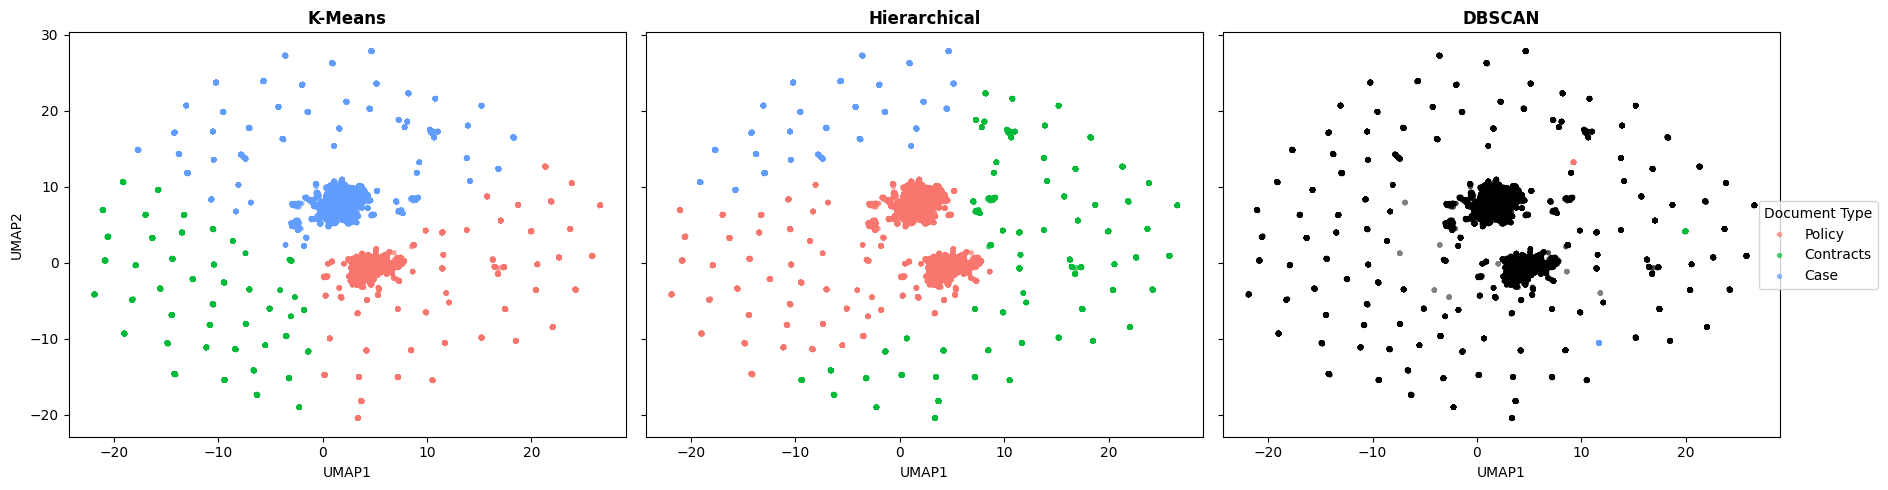

In [73]:
# Colors must match the values in DocType_* columns
color_dict = {
    "Contracts": "#00BA38",   # Green
    "Policy": "#F8766D",      # Red
    "Case": "#619CFF",        # Blue
    "Noise": "grey",
    "Other": "black"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

plots = [
    ("DocType_KMeans", "K-Means"),
    ("DocType_HC", "Hierarchical"),
    ("DocType_DBSCAN", "DBSCAN")
]

for ax, (col, title) in zip(axes, plots):
    sns.scatterplot(
        data=umap_df,
        x="UMAP1",
        y="UMAP2",
        hue=col,
        palette=color_dict,
        alpha=0.7,
        s=15,
        linewidth=0,
        ax=ax
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

    # Remove individual legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Add one common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Document Type",
    loc="center right",
    bbox_to_anchor=(1.05, 0.5)
)

plt.tight_layout()
plt.show()